In [1]:
import ast
from decision_maker import *
from explainer import estimate_interventional_probability_tabular, UtilityAlignedTabularExplainer
from fairlearn.datasets import fetch_acs_income, fetch_adult
import graphviz
from IPython.display import Image, display
import lime
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from ucimlrepo import fetch_ucirepo
from utils import *
from xgboost import XGBClassifier

/home/alexis/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RANDOM_SEED = 42

def test_equivalent(explainer, X_test, n_samples):
    res = []
    for i in range(n_samples):
        best_attribution = explainer.extract_utility_attribution(X_test.iloc[[i]])[0]["features"]
        best_explanation = list(ast.literal_eval(explainer.explain_instance(X_test.iloc[i])[0]["features"]))
        res.append({"Best attribution": best_attribution, "Best explication": best_explanation, "Belong": best_attribution in best_explanation})
    return pd.DataFrame(res)

## Loan Approval dataset

In [3]:
# Loan Approval dataset
loan_df = pd.read_csv("./LoanApproval.csv")
loan_df

X_loan = loan_df.drop(columns=["loan_status"])
y_loan = loan_df["loan_status"]

loan_features = X_loan.columns.to_list()
X_train_loan, X_test_loan, y_train_loan, y_test_loan = train_test_split(X_loan, y_loan, test_size=0.2, random_state=RANDOM_SEED)

X_train_loan = X_train_loan.reset_index(drop=True)
X_test_loan = X_test_loan.reset_index(drop=True)
y_train_loan = y_train_loan.reset_index(drop=True)
y_test_loan = y_test_loan.reset_index(drop=True)

categorical_cols = X_loan.select_dtypes(include=['object']).columns.tolist()
loan_categorical_indices = [loan_features.index(col) for col in categorical_cols]
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor_loan = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)], remainder='passthrough')

X_train_processed_loan = pd.DataFrame(preprocessor_loan.fit_transform(X_train_loan), columns=loan_features, index=X_train_loan.index)
X_test_processed_loan = pd.DataFrame(preprocessor_loan.transform(X_test_loan), columns=loan_features, index=X_test_loan.index)

loan_model = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
loan_model.fit(X_train_processed_loan, y_train_loan)

loan_class_names = [str(c) for c in sorted(loan_df['loan_status'].unique())]

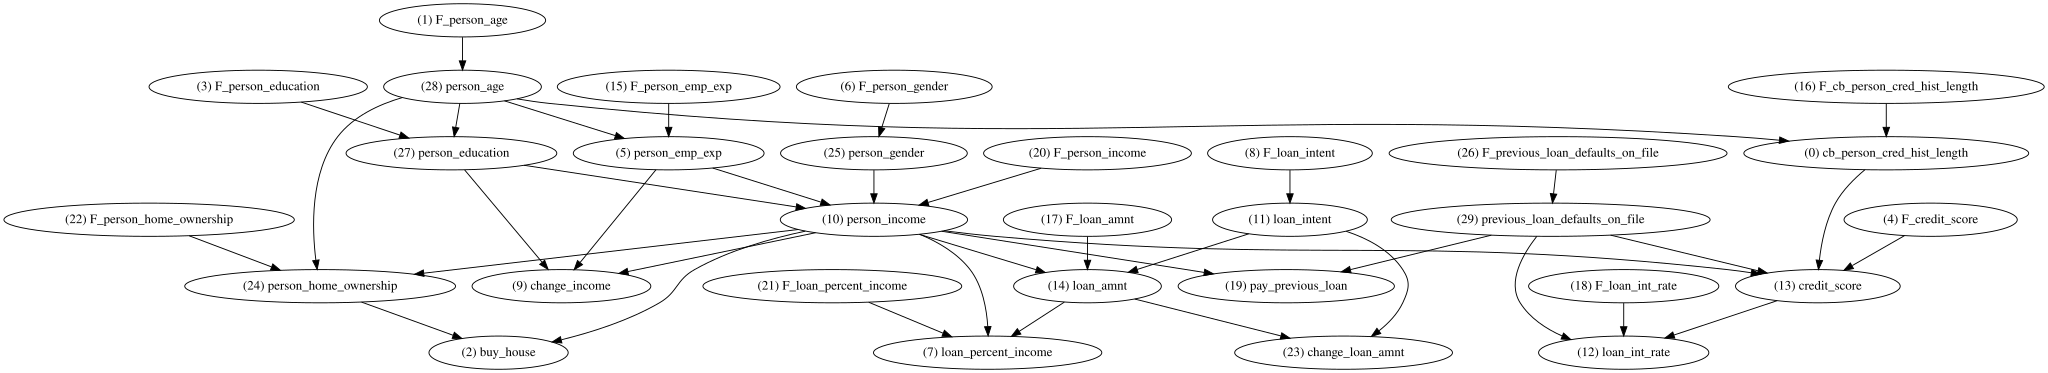

In [4]:
loan_actions = [
    "buy_house",
    "change_loan_amnt", 
    "change_income", 
    "pay_previous_loan"
]

loan_utility_matrix = np.array([[-12, 0], [-7, 0], [-12, 0], [-6, 0]])

loan_causal = CausalModel(features=loan_features, actions=loan_actions)

loan_causal.add_causal_edge("person_age", "person_emp_exp")
loan_causal.add_causal_edge("person_age", "cb_person_cred_hist_length")
loan_causal.add_causal_edge("person_age", "person_education")

loan_causal.add_causal_edge("person_education", "person_income")
loan_causal.add_causal_edge("person_emp_exp", "person_income")

loan_causal.add_causal_edge("person_income", "person_home_ownership")
loan_causal.add_causal_edge("person_age", "person_home_ownership")

loan_causal.add_causal_edge("cb_person_cred_hist_length", "credit_score")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "credit_score")
loan_causal.add_causal_edge("person_income", "credit_score")

loan_causal.add_causal_edge("loan_intent", "loan_amnt")
loan_causal.add_causal_edge("person_income", "loan_amnt")

loan_causal.add_causal_edge("loan_amnt", "loan_percent_income")
loan_causal.add_causal_edge("person_income", "loan_percent_income")

loan_causal.add_causal_edge("credit_score", "loan_int_rate")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "loan_int_rate")
#loan_causal.add_causal_edge("loan_percent_income", "loan_int_rate")
#loan_causal.add_causal_edge("person_home_ownership", "loan_int_rate")

loan_causal.add_causal_edge("person_gender", "person_income")

loan_causal.add_causal_edge("person_income", "buy_house")
loan_causal.add_causal_edge("person_home_ownership", "buy_house")

loan_causal.add_causal_edge("loan_amnt", "change_loan_amnt")
loan_causal.add_causal_edge("loan_intent", "change_loan_amnt")

loan_causal.add_causal_edge("person_income", "change_income")
loan_causal.add_causal_edge("person_education", "change_income")
loan_causal.add_causal_edge("person_emp_exp", "change_income")

loan_causal.add_causal_edge("previous_loan_defaults_on_file", "pay_previous_loan")
loan_causal.add_causal_edge("person_income", "pay_previous_loan")

dag = loan_causal.getDAG()
loan_dot = dag.toDot()
loan_graph = graphviz.Source(loan_dot)
display(loan_graph)

In [5]:
loan_explainer = UtilityAlignedTabularExplainer(
    model = loan_model,
    X_train=X_train_processed_loan,
    features=loan_features,
    actions=loan_actions,
    causal_model=loan_causal,
    utility_matrix=loan_utility_matrix
)

In [6]:
explanation = pd.DataFrame(loan_explainer.explain_instance(X_test_processed_loan.iloc[0]))
explanation

,features,prediction probability,utility score,preferrable action,information score
0,{'person_home_ownership'},"[0.7329098768834578, 0.2670901231165461]",-4.397459,pay_previous_loan,0.580343
1,"{'person_home_ownership', 'loan_int_rate'}","[0.7443560687421075, 0.2556439312578997]",-4.466136,pay_previous_loan,0.568451
2,{'loan_int_rate'},"[0.7450707747371473, 0.2549292252628573]",-4.470425,pay_previous_loan,0.567686
3,"{'person_home_ownership', 'loan_percent_income'}","[0.8208446315718143, 0.17915536842818183]",-4.925068,pay_previous_loan,0.470110
4,{'loan_percent_income'},"[0.8227592877731847, 0.1772407122268218]",-4.936556,pay_previous_loan,0.467184
5,"{'person_home_ownership', 'loan_int_rate', 'lo...","[0.8337975329317087, 0.16620246706828906]",-5.002785,pay_previous_loan,0.449813
6,"{'loan_int_rate', 'loan_percent_income'}","[0.8358476689730484, 0.16415233102695512]",-5.015086,pay_previous_loan,0.446492


In [7]:
attributions = pd.DataFrame(loan_explainer.extract_utility_attribution(X_test_processed_loan.iloc[[0]]))
attributions

,features,prediction probability,utility score,preferrable action,information score
0,person_home_ownership,"[0.7329098768834578, 0.2670901231165461]",-4.397459,pay_previous_loan,0.580343
1,loan_int_rate,"[0.7450707747371473, 0.2549292252628573]",-4.470425,pay_previous_loan,0.567686
2,loan_percent_income,"[0.8227592877731847, 0.1772407122268218]",-4.936556,pay_previous_loan,0.467184


In [8]:
explanation = pd.DataFrame(loan_explainer.explain_instance(X_test_processed_loan.iloc[1]))
explanation

,features,prediction probability,utility score,preferrable action,information score
0,{'person_home_ownership'},"[0.7337776735514242, 0.26622232644857446]",-4.402666,pay_previous_loan,0.579465
1,{'loan_int_rate'},"[0.7432364081741142, 0.25676359182588804]",-4.459418,pay_previous_loan,0.569644
2,"{'person_home_ownership', 'loan_int_rate'}","[0.7436092814818648, 0.25639071851813955]",-4.461656,pay_previous_loan,0.569248
3,{'loan_percent_income'},"[0.756516873922344, 0.24348312607764405]",-4.539101,pay_previous_loan,0.555062
4,"{'person_home_ownership', 'loan_percent_income'}","[0.7566516423336977, 0.24334835766630067]",-4.539910,pay_previous_loan,0.554909
5,"{'loan_int_rate', 'loan_percent_income'}","[0.7643298909850212, 0.23567010901497815]",-4.585979,pay_previous_loan,0.546037
6,"{'person_home_ownership', 'loan_int_rate', 'lo...","[0.7653214522204916, 0.23467854777950783]",-4.591929,pay_previous_loan,0.544868


In [9]:
attributions = pd.DataFrame(loan_explainer.extract_utility_attribution(X_test_processed_loan.iloc[[1]]))
attributions

,features,prediction probability,utility score,preferrable action,information score
0,person_home_ownership,"[0.7337776735514242, 0.2662223264485745]",-4.402666,pay_previous_loan,0.579465
1,loan_int_rate,"[0.7432364081741142, 0.25676359182588804]",-4.459418,pay_previous_loan,0.569644
2,loan_percent_income,"[0.756516873922344, 0.24348312607764405]",-4.539101,pay_previous_loan,0.555062


In [10]:
explanation = pd.DataFrame(loan_explainer.explain_instance(X_test_processed_loan.iloc[2]))
explanation

,features,prediction probability,utility score,preferrable action,information score
0,{'loan_percent_income'},"[0.5984246720211508, 0.40157532797885215]",-3.590548,pay_previous_loan,0.673645
1,"{'loan_int_rate', 'loan_percent_income'}","[0.6006041246979414, 0.39939587530206]",-3.603625,pay_previous_loan,0.672766
2,"{'person_home_ownership', 'loan_percent_income'}","[0.6016779282600342, 0.3983220717399668]",-3.610068,pay_previous_loan,0.672325
3,"{'person_home_ownership', 'loan_int_rate', 'lo...","[0.603584116019069, 0.39641588398093397]",-3.621505,pay_previous_loan,0.671532
4,{'person_home_ownership'},"[0.7332419984935338, 0.266758001506468]",-4.399452,pay_previous_loan,0.580008
5,"{'person_home_ownership', 'loan_int_rate'}","[0.7339403145014015, 0.26605968549860204]",-4.403642,pay_previous_loan,0.579300
6,{'loan_int_rate'},"[0.7347608522802056, 0.26523914771979823]",-4.408565,pay_previous_loan,0.578466


In [11]:
attributions = pd.DataFrame(loan_explainer.extract_utility_attribution(X_test_processed_loan.iloc[[2]]))
attributions

,features,prediction probability,utility score,preferrable action,information score
0,loan_percent_income,"[0.5984246720211508, 0.40157532797885215]",-3.590548,pay_previous_loan,0.673645
1,person_home_ownership,"[0.7332419984935337, 0.266758001506468]",-4.399452,pay_previous_loan,0.580008
2,loan_int_rate,"[0.7347608522802056, 0.26523914771979823]",-4.408565,pay_previous_loan,0.578466


In [12]:
test_equivalent(loan_explainer, X_test_processed_loan, 20)

,Best attribution,Best explication,Belong
0,person_home_ownership,[person_home_ownership],True
1,person_home_ownership,[person_home_ownership],True
2,loan_percent_income,[loan_percent_income],True
3,loan_percent_income,[loan_percent_income],True
4,loan_percent_income,[loan_percent_income],True
5,person_home_ownership,"[person_home_ownership, loan_int_rate]",True
6,person_home_ownership,[person_home_ownership],True
7,loan_percent_income,"[loan_percent_income, loan_int_rate]",True
8,person_home_ownership,[person_home_ownership],True
9,person_home_ownership,"[person_home_ownership, loan_percent_income]",True


## Adult Income

In [13]:
X_adult, y_adult = shap.datasets.adult()
X_adult.columns = X_adult.columns.str.replace(r'[\s\-]+', '_', regex=True)
X_adult = X_adult.astype(float)
y_adult = y_adult.astype(int)

In [14]:
adult_features = X_adult.columns.to_list()
X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(X_adult, y_adult, test_size=0.2, random_state=RANDOM_SEED)

X_train_adult = X_train_adult.reset_index(drop=True)
X_test_adult = X_test_adult.reset_index(drop=True)

adult_model = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
adult_model.fit(X_train_adult, y_train_adult)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


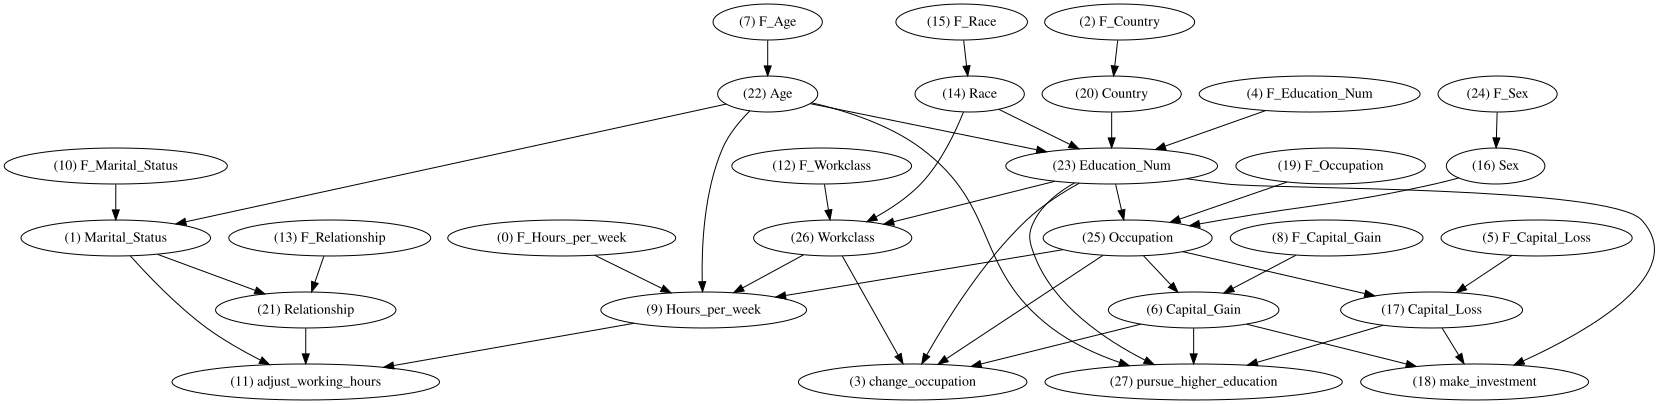

In [15]:
adult_actions = [
    'pursue_higher_education',
    'change_occupation',
    'adjust_working_hours',
    'make_investment'
]

adult_utility_matrix = np.array([
    [-5, 10],  # pursue_higher_education
    [-3,  7],  # change_occupation
    [-1,  4],  # adjust_working_hours
    [-4,  8]   # make_investment
])

adult_causal = CausalModel(features=adult_features, actions=adult_actions)

adult_causal.add_causal_edge('Age', 'Education_Num')
adult_causal.add_causal_edge('Age', 'Marital_Status')
adult_causal.add_causal_edge('Age', 'Hours_per_week')

adult_causal.add_causal_edge('Country', 'Education_Num')
adult_causal.add_causal_edge('Race', 'Education_Num')
adult_causal.add_causal_edge('Sex', 'Occupation')

adult_causal.add_causal_edge('Education_Num', 'Occupation')
adult_causal.add_causal_edge('Education_Num', 'Workclass')

adult_causal.add_causal_edge('Marital_Status', 'Relationship')

adult_causal.add_causal_edge('Occupation', 'Hours_per_week')
adult_causal.add_causal_edge('Occupation', 'Capital_Gain')
adult_causal.add_causal_edge('Occupation', 'Capital_Loss')

adult_causal.add_causal_edge('Race', 'Workclass')

adult_causal.add_causal_edge('Workclass', 'Hours_per_week')

adult_causal.add_causal_edge('Age', 'pursue_higher_education')
adult_causal.add_causal_edge('Education_Num', 'pursue_higher_education')
adult_causal.add_causal_edge('Capital_Gain', 'pursue_higher_education')
adult_causal.add_causal_edge('Capital_Loss', 'pursue_higher_education')

adult_causal.add_causal_edge('Occupation', 'change_occupation')
adult_causal.add_causal_edge('Education_Num', 'change_occupation')
adult_causal.add_causal_edge('Workclass', 'change_occupation')
adult_causal.add_causal_edge('Capital_Gain', 'change_occupation')

adult_causal.add_causal_edge('Hours_per_week', 'adjust_working_hours')
adult_causal.add_causal_edge('Marital_Status', 'adjust_working_hours')
adult_causal.add_causal_edge('Relationship', 'adjust_working_hours')

adult_causal.add_causal_edge('Capital_Gain', 'make_investment')
adult_causal.add_causal_edge('Capital_Loss', 'make_investment')
adult_causal.add_causal_edge('Education_Num', 'make_investment')

dag = adult_causal.getDAG()
adult_dot = dag.toDot()
adult_graph = graphviz.Source(adult_dot)

display(adult_graph)

In [16]:
adult_explainer = UtilityAlignedTabularExplainer(
    model = adult_model,
    X_train=X_train_adult,
    features=adult_features,
    actions=adult_actions,
    causal_model=adult_causal,
    utility_matrix=adult_utility_matrix
)

In [17]:
test_equivalent(adult_explainer, X_test_adult, 20)

,Best attribution,Best explication,Belong
0,Capital_Loss,[Capital_Loss],True
1,Relationship,"[Relationship, Hours_per_week]",True
2,Relationship,"[Relationship, Hours_per_week]",True
3,Capital_Loss,[Capital_Loss],True
4,Hours_per_week,[Hours_per_week],True
5,Relationship,"[Relationship, Hours_per_week]",True
6,Capital_Gain,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
7,Capital_Loss,[Capital_Loss],True
8,Capital_Loss,[Capital_Loss],True
9,Relationship,"[Relationship, Capital_Gain, Hours_per_week]",True


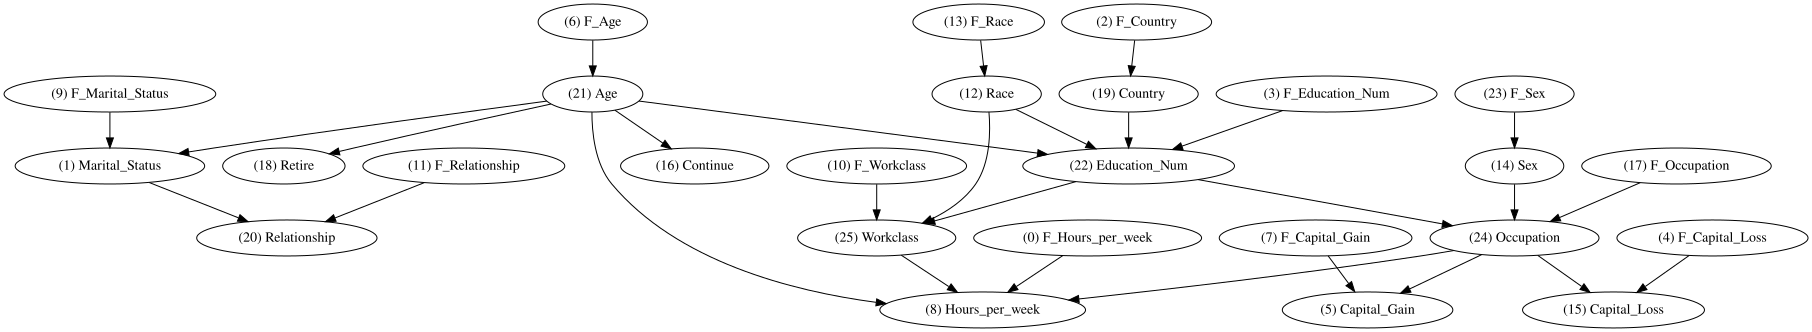

In [32]:
adult_actions_2 = ["Retire", "Continue"]

adult_utility_matrix_2 = np.array([
    [100, 0],
    [0, 100]
])

adult_causal_2 = CausalModel(features=adult_features, actions=adult_actions_2)

adult_causal_2.add_causal_edge('Age', 'Education_Num')
adult_causal_2.add_causal_edge('Age', 'Marital_Status')
adult_causal_2.add_causal_edge('Age', 'Hours_per_week')

adult_causal_2.add_causal_edge('Country', 'Education_Num')
adult_causal_2.add_causal_edge('Race', 'Education_Num')
adult_causal_2.add_causal_edge('Sex', 'Occupation')

adult_causal_2.add_causal_edge('Education_Num', 'Occupation')
adult_causal_2.add_causal_edge('Education_Num', 'Workclass')

adult_causal_2.add_causal_edge('Marital_Status', 'Relationship')

adult_causal_2.add_causal_edge('Occupation', 'Hours_per_week')
adult_causal_2.add_causal_edge('Occupation', 'Capital_Gain')
adult_causal_2.add_causal_edge('Occupation', 'Capital_Loss')

adult_causal_2.add_causal_edge('Race', 'Workclass')

adult_causal_2.add_causal_edge('Workclass', 'Hours_per_week')

adult_causal_2.add_causal_edge('Age', 'Retire')
adult_causal_2.add_causal_edge('Age', 'Continue')

dag = adult_causal_2.getDAG()
adult_dot = dag.toDot()
adult_graph = graphviz.Source(adult_dot)

display(adult_graph)

adult_explainer_2 = UtilityAlignedTabularExplainer(
    model = adult_model,
    X_train=X_train_adult,
    features=adult_features,
    actions=adult_actions_2,
    causal_model=adult_causal_2,
    utility_matrix=adult_utility_matrix_2
)

In [22]:
test_equivalent(adult_explainer_2, X_test_adult, 20)

,Best attribution,Best explication,Belong
0,Relationship,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
1,Capital_Gain,"[Capital_Loss, Hours_per_week, Capital_Gain]",True
2,Capital_Gain,"[Capital_Loss, Capital_Gain]",True
3,Relationship,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
4,Relationship,"[Capital_Loss, Relationship, Capital_Gain]",True
5,Capital_Gain,"[Capital_Loss, Capital_Gain]",True
6,Capital_Gain,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
7,Relationship,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
8,Relationship,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
9,Capital_Gain,"[Capital_Loss, Hours_per_week, Capital_Gain]",True


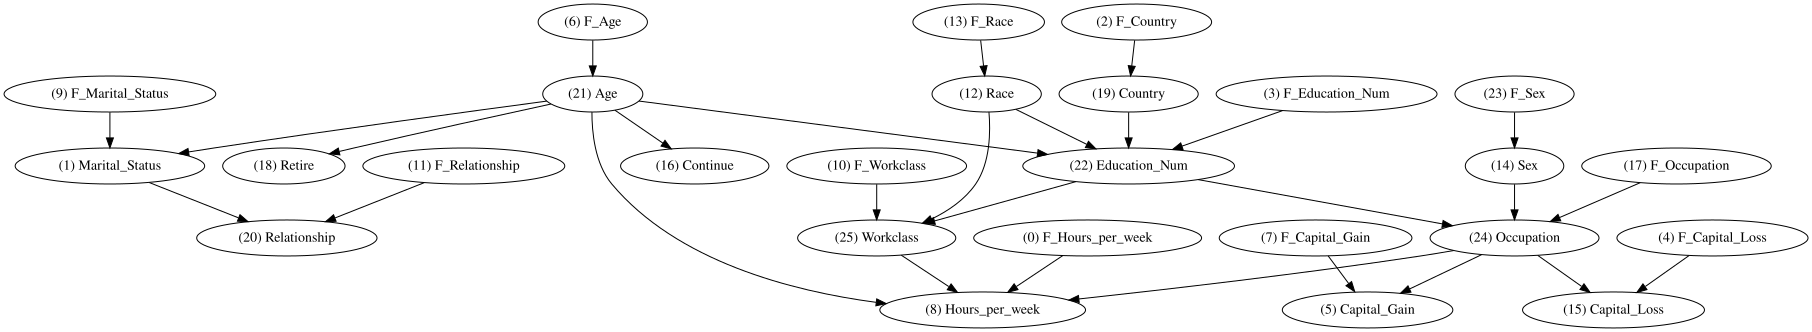

In [33]:
adult_utility_matrix_3 = np.array([
    [10, 0],
    [0, 1000]
])

dag = adult_causal_2.getDAG()
adult_dot = dag.toDot()
adult_graph = graphviz.Source(adult_dot)

display(adult_graph)

adult_explainer_3 = UtilityAlignedTabularExplainer(
    model = adult_model,
    X_train=X_train_adult,
    features=adult_features,
    actions=adult_actions_2,
    causal_model=adult_causal_2,
    utility_matrix=adult_utility_matrix_3
)

In [34]:
test_equivalent(adult_explainer_3, X_test_adult, 20)

,Best attribution,Best explication,Belong
0,Capital_Loss,[Capital_Loss],True
1,Relationship,"[Relationship, Hours_per_week]",True
2,Relationship,"[Relationship, Hours_per_week]",True
3,Capital_Loss,[Capital_Loss],True
4,Hours_per_week,[Hours_per_week],True
5,Relationship,"[Relationship, Hours_per_week]",True
6,Capital_Gain,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
7,Capital_Loss,[Capital_Loss],True
8,Capital_Loss,[Capital_Loss],True
9,Relationship,"[Relationship, Capital_Gain, Hours_per_week]",True


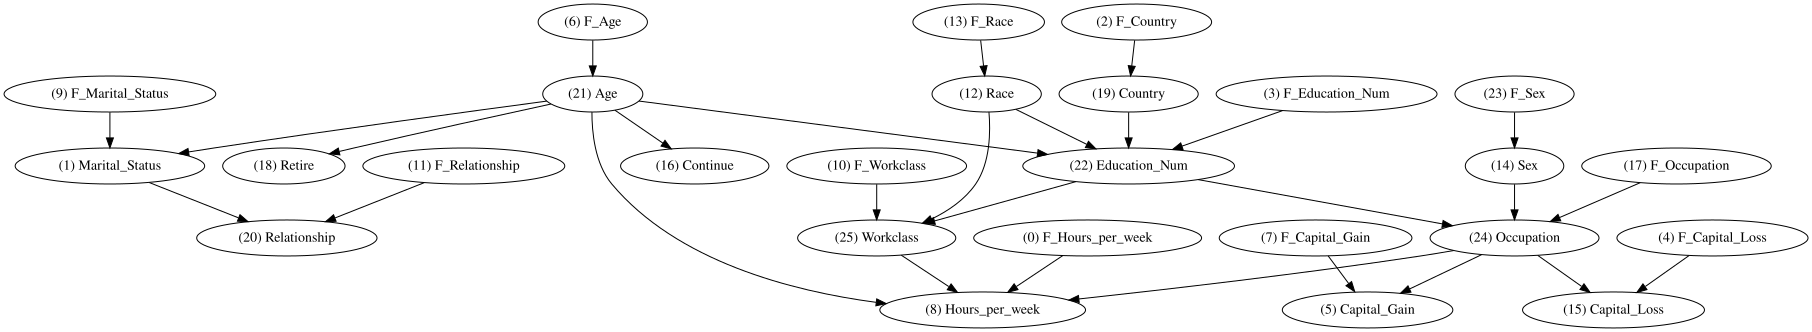

In [35]:
adult_utility_matrix_4 = np.array([
    [-1000, 5],
    [-50, 10]
])

dag = adult_causal_2.getDAG()
adult_dot = dag.toDot()
adult_graph = graphviz.Source(adult_dot)

display(adult_graph)

adult_explainer_4 = UtilityAlignedTabularExplainer(
    model = adult_model,
    X_train=X_train_adult,
    features=adult_features,
    actions=adult_actions_2,
    causal_model=adult_causal_2,
    utility_matrix=adult_utility_matrix_4
)

In [36]:
test_equivalent(adult_explainer_4, X_test_adult, 20)

,Best attribution,Best explication,Belong
0,Capital_Loss,[Capital_Loss],True
1,Relationship,"[Relationship, Hours_per_week]",True
2,Relationship,"[Relationship, Hours_per_week]",True
3,Capital_Loss,[Capital_Loss],True
4,Hours_per_week,[Hours_per_week],True
5,Relationship,"[Relationship, Hours_per_week]",True
6,Capital_Gain,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
7,Capital_Loss,[Capital_Loss],True
8,Capital_Loss,[Capital_Loss],True
9,Relationship,"[Relationship, Capital_Gain, Hours_per_week]",True


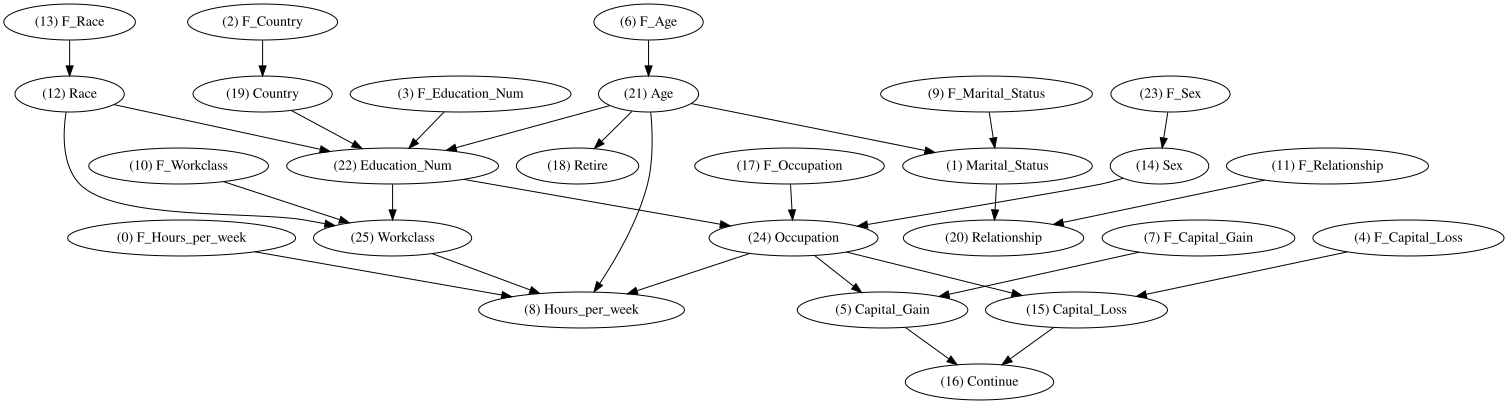

In [38]:
adult_causal_3 = CausalModel(features=adult_features, actions=adult_actions_2)

adult_causal_3.add_causal_edge('Age', 'Education_Num')
adult_causal_3.add_causal_edge('Age', 'Marital_Status')
adult_causal_3.add_causal_edge('Age', 'Hours_per_week')

adult_causal_3.add_causal_edge('Country', 'Education_Num')
adult_causal_3.add_causal_edge('Race', 'Education_Num')
adult_causal_3.add_causal_edge('Sex', 'Occupation')

adult_causal_3.add_causal_edge('Education_Num', 'Occupation')
adult_causal_3.add_causal_edge('Education_Num', 'Workclass')

adult_causal_3.add_causal_edge('Marital_Status', 'Relationship')

adult_causal_3.add_causal_edge('Occupation', 'Hours_per_week')
adult_causal_3.add_causal_edge('Occupation', 'Capital_Gain')
adult_causal_3.add_causal_edge('Occupation', 'Capital_Loss')

adult_causal_3.add_causal_edge('Race', 'Workclass')

adult_causal_3.add_causal_edge('Workclass', 'Hours_per_week')

adult_causal_3.add_causal_edge('Age', 'Retire')
adult_causal_3.add_causal_edge('Capital_Gain', 'Continue')
adult_causal_3.add_causal_edge('Capital_Loss', 'Continue')

dag = adult_causal_3.getDAG()
adult_dot = dag.toDot()
adult_graph = graphviz.Source(adult_dot)

display(adult_graph)

adult_explainer_5 = UtilityAlignedTabularExplainer(
    model = adult_model,
    X_train=X_train_adult,
    features=adult_features,
    actions=adult_actions_2,
    causal_model=adult_causal_3,
    utility_matrix=adult_utility_matrix_2
)

In [39]:
test_equivalent(adult_explainer_5, X_test_adult, 20)

,Best attribution,Best explication,Belong
0,Relationship,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
1,Capital_Gain,"[Capital_Loss, Hours_per_week, Capital_Gain]",True
2,Capital_Gain,"[Capital_Loss, Capital_Gain]",True
3,Relationship,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
4,Relationship,"[Capital_Loss, Relationship, Capital_Gain]",True
5,Capital_Gain,"[Capital_Loss, Capital_Gain]",True
6,Capital_Gain,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
7,Relationship,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
8,Relationship,"[Capital_Loss, Relationship, Capital_Gain, Hou...",True
9,Capital_Gain,"[Capital_Loss, Hours_per_week, Capital_Gain]",True


## UCI Heart Disease

In [23]:
heart_disease = fetch_ucirepo(id=45)
X_heart = heart_disease.data.features.dropna()
y_heart = heart_disease.data.targets.loc[X_heart.index]
X_heart = X_heart.astype(float)

In [24]:
heart_features = X_heart.columns.to_list()

X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(X_heart, y_heart, test_size=0.2, random_state=RANDOM_SEED)

X_train_heart = X_train_heart.reset_index(drop=True)
X_test_heart = X_test_heart.reset_index(drop=True)
y_train_heart = y_train_heart.reset_index(drop=True)
y_test_heart = y_test_heart.reset_index(drop=True)

categorical_cols = X_heart.select_dtypes(include=['object']).columns.tolist()
heart_categorical_indices = [heart_features.index(col) for col in categorical_cols]

heart_model = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
heart_model.fit(X_train_heart, y_train_heart)

heart_class_names = [str(c) for c in sorted(np.unique(y_heart.values))]

/home/alexis/.local/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [25]:
def add_pathophysiology_edges(causal_model):
    causal_model.add_causal_edge('age', 'trestbps')
    causal_model.add_causal_edge('age', 'chol')
    causal_model.add_causal_edge('age', 'thalach')

    causal_model.add_causal_edge('sex', 'chol')
    causal_model.add_causal_edge('sex', 'thal')
    
    causal_model.add_causal_edge('trestbps', 'cp')
    causal_model.add_causal_edge('chol', 'cp')
    causal_model.add_causal_edge('fbs', 'cp')
    causal_model.add_causal_edge('cp', 'exang')
    
    causal_model.add_causal_edge('chol', 'ca')
    causal_model.add_causal_edge('trestbps', 'restecg')
    causal_model.add_causal_edge('thalach', 'oldpeak')
    causal_model.add_causal_edge('oldpeak', 'slope')

### Patient-based

In [26]:
patient_actions = ['change_diet', 'increase_physical_activity', 'monitor_vitals_at_home', 'seek_immediate_care']

patient_utility_matrix = np.array([
    [ 0,  5,  5,   2,   1],  # change_diet
    [ 2,  5, -5, -10, -15],  # increase_physical_activity
    [-1,  2,  5,   5,   2],  # monitor_vitals_at_home
    [-5, -2,  2,  10,  15]   # seek_immediate_care
])

patient_causal = CausalModel(features=heart_features, actions=patient_actions)
add_pathophysiology_edges(patient_causal)

patient_causal.add_causal_edge('chol', 'change_diet')
patient_causal.add_causal_edge('trestbps', 'change_diet')
patient_causal.add_causal_edge('fbs', 'change_diet')

patient_causal.add_causal_edge('age', 'increase_physical_activity')
patient_causal.add_causal_edge('thalach', 'increase_physical_activity')
patient_causal.add_causal_edge('cp', 'increase_physical_activity')

patient_causal.add_causal_edge('trestbps', 'monitor_vitals_at_home')
patient_causal.add_causal_edge('fbs', 'monitor_vitals_at_home')

patient_causal.add_causal_edge('cp', 'seek_immediate_care')
patient_causal.add_causal_edge('exang', 'seek_immediate_care')

In [27]:
patient_explainer = UtilityAlignedTabularExplainer(
    model = heart_model,
    X_train=X_train_heart,
    features=heart_features,
    actions=patient_actions,
    causal_model=patient_causal,
    utility_matrix=patient_utility_matrix
)

In [28]:
test_equivalent(patient_explainer, X_test_heart, 20)

,Best attribution,Best explication,Belong
0,slope,"[slope, restecg]",True
1,ca,"[ca, restecg]",True
2,restecg,[restecg],True
3,ca,"[ca, exang, slope, restecg]",True
4,restecg,[restecg],True
5,ca,[ca],True
6,ca,"[ca, restecg]",True
7,ca,"[ca, thal, restecg]",True
8,thal,"[exang, slope, thal]",True
9,exang,"[exang, restecg]",True


### Doctor-based

In [29]:
doctor_actions = ['prescribe_statins', 'prescribe_beta_blockers', 'order_angiography', 'refer_to_surgery']

doctor_utility_matrix = np.array([
    [-2,  5,  5,   3,   1],  # prescribe_statins
    [-3,  3,  6,   5,   2],  # prescribe_beta_blockers
    [-5,  0,  6,   8,  10],  # order_angiography
    [-10,-5, -2,  10,  15]   # refer_to_surgery
])

doctor_causal = CausalModel(features=heart_features, actions=doctor_actions)
add_pathophysiology_edges(doctor_causal)

doctor_causal.add_causal_edge('chol', 'prescribe_statins')
doctor_causal.add_causal_edge('age', 'prescribe_statins')

doctor_causal.add_causal_edge('trestbps', 'prescribe_beta_blockers')
doctor_causal.add_causal_edge('thalach', 'prescribe_beta_blockers')
doctor_causal.add_causal_edge('oldpeak', 'prescribe_beta_blockers')

doctor_causal.add_causal_edge('cp', 'order_angiography')
doctor_causal.add_causal_edge('slope', 'order_angiography')
doctor_causal.add_causal_edge('thal', 'order_angiography')

doctor_causal.add_causal_edge('ca', 'refer_to_surgery')
doctor_causal.add_causal_edge('thal', 'refer_to_surgery')
doctor_causal.add_causal_edge('oldpeak', 'refer_to_surgery')

In [30]:
doctor_explainer = UtilityAlignedTabularExplainer(
    model = heart_model,
    X_train=X_train_heart,
    features=heart_features,
    actions=doctor_actions,
    causal_model=doctor_causal,
    utility_matrix=doctor_utility_matrix
)

In [31]:
test_equivalent(doctor_explainer, X_test_heart, 20)

,Best attribution,Best explication,Belong
0,slope,"[slope, restecg]",True
1,ca,"[ca, restecg]",True
2,restecg,[restecg],True
3,ca,"[ca, slope, restecg]",True
4,restecg,[restecg],True
5,ca,"[ca, restecg]",True
6,ca,[ca],True
7,ca,"[ca, thal]",True
8,thal,"[exang, slope, thal, restecg]",True
9,exang,"[exang, restecg]",True
